# 1.NumPy Operations

In [1]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])

print("Original array:", arr)
print("Add 2:", arr + 2)
print("Multiply by 2:", arr * 2)
print("Square:", arr ** 2)

Original array: [1 2 3 4 5]
Add 2: [3 4 5 6 7]
Multiply by 2: [ 2  4  6  8 10]
Square: [ 1  4  9 16 25]


In [2]:
import time

arr = np.arange(1_000_000)

# Python loop
start = time.perf_counter()

result_loop = []
for x in arr:
    result_loop.append(x * 2)

loop_time = time.perf_counter() - start


# NumPy vectorized operation
start = time.perf_counter()

result_vectorized = arr * 2

vectorized_time = time.perf_counter() - start


print("Loop time:", loop_time)
print("Vectorized time:", vectorized_time)

Loop time: 0.05018258304335177
Vectorized time: 0.0008637909777462482


# 2.Dataset Loading

In [3]:
import pandas as pd
from pathlib import Path

In [4]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "starter_data.csv"

print(DATA_PATH)
print(DATA_PATH.exists())

/Users/xuan/Desktop/bootcamp_Jiaxuan_Li/homework/homework3/data/raw/starter_data.csv
True


In [5]:
df = pd.read_csv(DATA_PATH)

In [6]:
df.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  10 non-null     str  
 1   value     10 non-null     int64
 2   date      10 non-null     str  
dtypes: int64(1), str(2)
memory usage: 372.0 bytes


# 3.Summary Statistics

In [8]:
summary = df.describe()

summary

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [9]:
grouped = df.groupby("category")["value"].agg(
    ["count", "mean", "min", "max"]
)

grouped

,count,mean,min,max
category,,,,
A,4,11.500000,10,13
B,3,15.666667,14,18
C,3,27.666667,25,30


# 4.Save Outputs

In [10]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(OUTPUT_DIR / "summary.csv")

Matplotlib is building the font cache; this may take a moment.


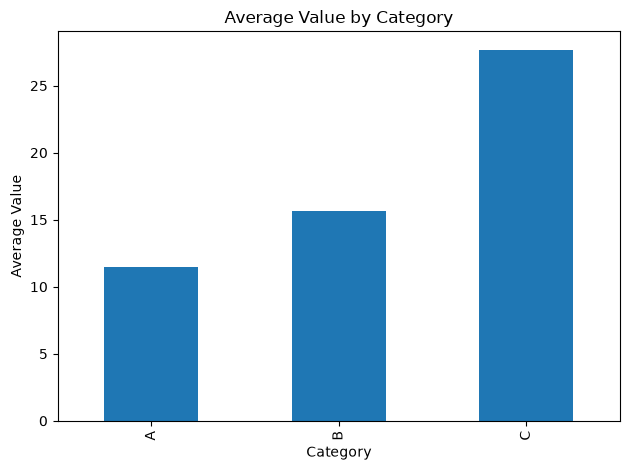

In [ ]:
import matplotlib.pyplot as plt

df.groupby("category")["value"].mean().plot(kind="bar")

plt.title("Average Value by Category")
plt.xlabel("Category")
plt.ylabel("Average Value")
plt.tight_layout()

# plt.savefig(OUTPUT_DIR / "summary_plot.png")
plt.show()

# 5.Reusable Function

In [12]:
def get_summary_stats(df, group_col=None):
    """
    Generate basic summary statistics for a pandas DataFrame.

    Parameters:
        df: pandas DataFrame
        group_col: optional column name used for grouping

    Returns:
        A dictionary containing summary statistics
    """

    results = {}

    # Basic dataset information
    results["shape"] = df.shape
    results["columns"] = list(df.columns)

    # Missing values for each column
    results["missing_values"] = df.isnull().sum()

    # Summary statistics for numeric columns
    results["numeric_summary"] = df.describe()

    # Optional groupby analysis
    if group_col is not None:
        if group_col in df.columns:
            results["group_summary"] = (
                df.groupby(group_col)
                  .mean(numeric_only=True)
            )
        else:
            print(f"Warning: '{group_col}' is not a valid column.")

    return results

In [13]:
summary_func = get_summary_stats(df, "category")

summary_func

{'shape': (10, 3),
 'columns': ['category', 'value', 'date'],
 'missing_values': category    0
 value       0
 date        0
 dtype: int64,
 'numeric_summary':            value
 count  10.000000
 mean   17.600000
 std     7.381659
 min    10.000000
 25%    12.250000
 50%    14.500000
 75%    23.250000
 max    30.000000,
 'group_summary':               value
 category           
 A         11.500000
 B         15.666667
 C         27.666667}